In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import bernoulli, binom, poisson
from scipy.stats import zscore
from scipy.stats import boxcox

from statsmodels.graphics.gofplots import qqplot

ModuleNotFoundError: No module named 'powerlaw'

# PART A — THEORETICAL FOUNDATION


1. What is Statistical Distribution?

A statistical distribution describes how data values are spread across different ranges. It helps understand patterns, probabilities, and behavior of data.

Example

Customer transaction amounts:

Most customers spend ₹1000–₹3000
Few customers spend ₹10000+

This spread of values forms a distribution.

Types
Normal Distribution
Bernoulli Distribution
Binomial Distribution
Poisson Distribution
Log-Normal Distribution
Importance
Helps in prediction
Identifies trends
Used in machine learning and statistics

2. What is a Q-Q Plot and Why is it Used?

Q-Q (Quantile-Quantile) Plot compares dataset distribution with normal distribution.

It checks whether data follows a normal distribution.

Interpretation
Straight line → Normally distributed
Curved line → Not normal
Uses
Check normality
Detect skewness
Detect outliers

3. Difference Between Discrete and Continuous Distribution
Discrete Distribution	Continuous Distribution
Countable values	Infinite values
Example: Number of transactions	Example: Transaction amount
Uses integers	Uses decimal values
Example
Discrete → 5 transactions/day
Continuous → ₹2450.75 transaction amount
4. What is Bernoulli Distribution?

Bernoulli distribution has only two outcomes:

Success = 1
Failure = 0
Formula

P(X=x)=px(1−p)1−x

Example

Transaction Status:

Success
Fail
Use

Used for binary classification problems.

5. What is Binomial Distribution?

Binomial distribution represents number of successes in multiple trials.

Conditions
Fixed number of trials
Two outcomes
Same probability

Example

Out of 10 transactions:

Probability of 7 successful transactions


6. Explain Log-Normal Distribution

If logarithm of data follows normal distribution, then original data is Log-Normal.

Characteristics
Right-skewed
Large values possible
Common in financial data
Example

Transaction amounts, stock prices, salaries.

Why Used?

Many e-commerce transaction datasets follow Log-Normal distribution.

7. Explain Power Law Distribution

Power Law distribution contains many small values and few extremely large values.

Characteristics
Heavy tail
Rare large events
Example
Very few customers spend huge amounts
Social media followers
Importance

Helps detect high-value customers.

8. What is Box-Cox Transformation?

Box-Cox transformation converts non-normal data into near-normal data.

Used to stabilize variance and improve model performance.

Uses
Reduces skewness
Improves normality


9. Explain Poisson Distribution with Example

Poisson distribution models count of events occurring in fixed interval.

Example

Number of transactions per day.

Uses
Event counting
Call arrivals
Website visits

10. What is Z-score Probability?

Z-score measures how far a value is from mean.

Example

Checking whether ₹5000 transaction is unusually high.

11. Difference Between PDF and CDF

PDF	

Probability Density Function	
Gives density at point	
Used in continuous distribution	

CDF

Cumulative Distribution Function
Gives cumulative probability
Used for total probability


# PART B — DATA ANALYSIS & TESTING TASKS

In [2]:
df = pd.read_csv(r"C:\Users\HP\Downloads\spread_locator_dataset - spread_locator_dataset.csv.csv")

df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      220 non-null    object 
 1   customer_id         220 non-null    object 
 2   transaction_amount  220 non-null    float64
 3   transaction_date    220 non-null    object 
 4   transaction_count   220 non-null    int64  
 5   region              220 non-null    object 
 6   transaction_status  220 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 12.2+ KB
None


In [8]:
print(df.describe())

       transaction_amount  transaction_count
count          220.000000         220.000000
mean          3365.192409           2.854545
std           1985.705409           1.797189
min            804.420000           0.000000
25%           2124.205000           1.750000
50%           3077.715000           3.000000
75%           3950.737500           4.000000
max          20462.840000           9.000000


In [5]:
print(df.isnull().sum())

transaction_id        0
customer_id           0
transaction_amount    0
transaction_date      0
transaction_count     0
region                0
transaction_status    0
dtype: int64


In [13]:
# Bernoulli Distribution

df['status_binary'] = df['transaction_status'].map({'Success':1,'Fail':0})
p = df['status_binary'].mean()
print("Probability of Success:", p)

Probability of Success: 0.44545454545454544


In [14]:
n = 10
x = 7

binomial_prob = binom.pmf(x, n, p)
print(binomial_prob)

0.07122237631521985


In [ ]:
# Average transaction count

lam = df['transaction_count'].mean()
print("Lambda:", lam)

# Probability of 5 transactions

poisson_probability = poisson.pmf(5, lam)
print("Poisson Probability:", poisson_probability)

Lambda: 2.8545454545454545
Poisson Probability: 0.09094738770519475


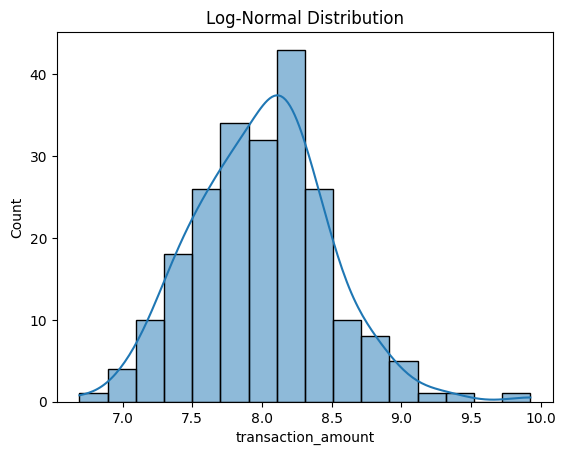

In [17]:
log_data = np.log(df['transaction_amount'])
sns.histplot(log_data, kde=True)
plt.title("Log-Normal Distribution")
plt.show()

ModuleNotFoundError: No module named 'powerlaw'

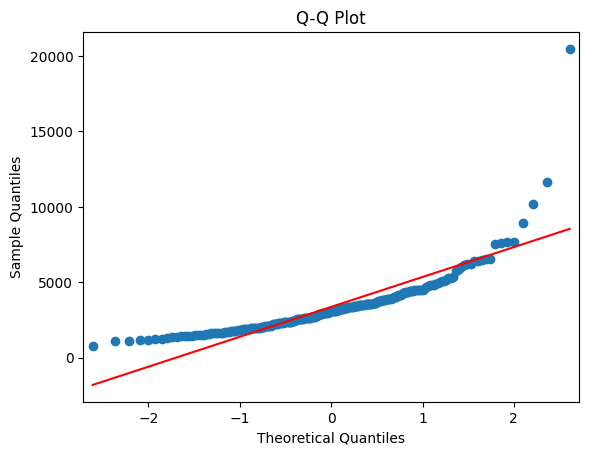

In [21]:
qqplot(df['transaction_amount'], line='s')
plt.title("Q-Q Plot")
plt.show()

Lambda Value: -0.18083391951050778


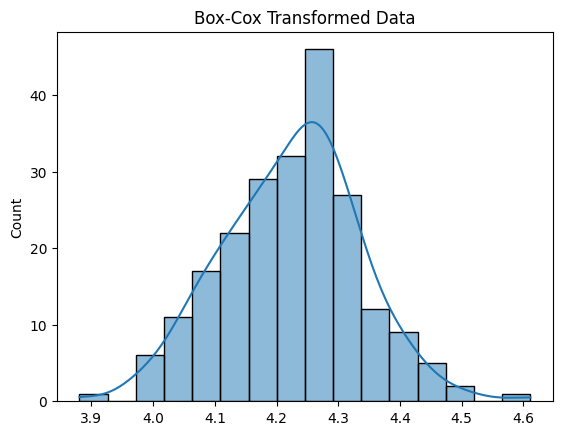

In [ ]:
transformed_data, lambda_value = boxcox(df['transaction_amount'])
print("Lambda Value:", lambda_value)
sns.histplot(transformed_data, kde=True)
plt.title("Box-Cox Transformed Data")
plt.show()

In [24]:
mean = df['transaction_amount'].mean()

std = df['transaction_amount'].std()

z = (5000 - mean) / std

print("Z-score:", z)

Z-score: 0.8232880785671723


In [25]:
probability = 1 - stats.norm.cdf(z)

print("Probability of Transaction > 5000:", probability)

Probability of Transaction > 5000: 0.20517209567554384


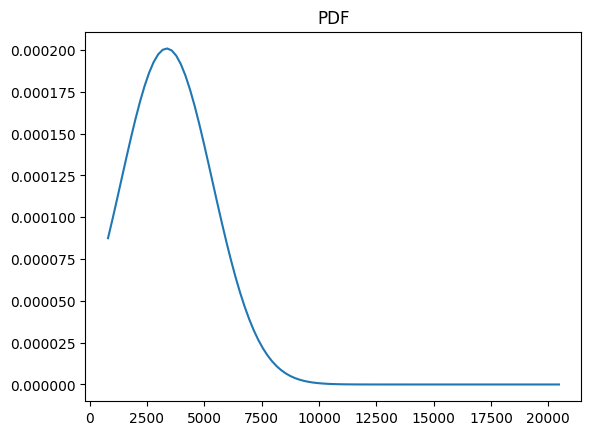

In [26]:
x = np.linspace(
    df['transaction_amount'].min(),
    df['transaction_amount'].max(),
    100
)

pdf = stats.norm.pdf(x, mean, std)

plt.plot(x, pdf)

plt.title("PDF")

plt.show()

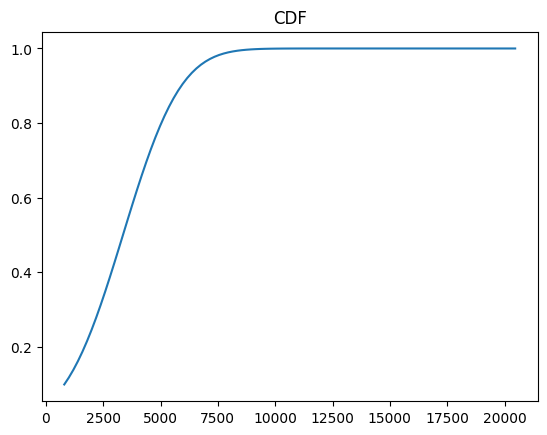

In [27]:
cdf = stats.norm.cdf(x, mean, std)

plt.plot(x, cdf)

plt.title("CDF")

plt.show()